# Nb to explore visual HB activity estimation

In [ ]:
import sys, cv2
import pandas as pd
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.width', 1000)  # Set a wide width for display
pd.set_option('display.colheader_justify', 'center')  # Align column headers
sys.path.append('RHCVisualisation/RHCImaging')
from RHCVisualisation.RHCImaging.libimage import fetchImagesPaths
from RHCVisualisation.RHCImaging.VideoManagment.videolib import initVideoWriter
import matplotlib.pyplot as plt
import numpy as np
from libActivity import computeRpiActivities
from tqdm import tqdm

from dask.distributed import Client
# Start a client using all CPUs of this machine
client = Client()
client

INFO:distributed.http.proxy:To route to workers diagnostics web server please install jupyter-server-proxy: python -m pip install jupyter-server-proxy
/opt/miniconda3/envs/imaging/lib/python3.11/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 57438 instead
  warnings.warn(
INFO:distributed.scheduler:State start
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-84qr7h5s', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/worker-ppb2f5oq', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6sd80000gr/T/dask-scratch-space/scheduler-ciuvnhzk', purging
INFO:distributed.diskutils:Found stale lock file and directory '/var/folders/w2/m4mvm5pj37107n10n7fs6

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: http://127.0.0.1:57438/status,
Dashboard: http://127.0.0.1:57438/status,Workers: 4
Total threads: 12,Total memory: 32.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:57439,Workers: 0
Dashboard: http://127.0.0.1:57438/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:57451,Total threads: 3
Dashboard: http://127.0.0.1:57453/status,Memory: 8.00 GiB
Nanny: tcp://127.0.0.1:57442,


INFO:distributed.nanny:Closing Nanny gracefully at 'tcp://127.0.0.1:57442'. Reason: worker-close
INFO:distributed.nanny:Closing Nanny gracefully at 'tcp://127.0.0.1:57448'. Reason: worker-close
INFO:distributed.nanny:Closing Nanny gracefully at 'tcp://127.0.0.1:57444'. Reason: worker-close
INFO:distributed.nanny:Closing Nanny gracefully at 'tcp://127.0.0.1:57446'. Reason: worker-close
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:57455; closing.
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:57462; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:57451 name: 0 (stimulus_id='handle-worker-cleanup-1784274099.920079')
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:57460 name: 3 (stimulus_id='handle-worker-cleanup-1784274099.921751')
INFO:distributed.core:Received 'close-stream' from tcp://127.0.0.1:57456; closing.
INFO:distributed.scheduler:Remove worker addr: tcp://127.0.0.1:57452 name: 1 (stimulus_id='handle

## Congfiguration

In [2]:
hive_nb = 1

rootpath_imgs = '/Users/cyrilmonette/Library/CloudStorage/SynologyDrive-data/24.11-25.01_metabolism_OH/Images/'
img_freq = "1min" # Sampling frequency of images
start_ts = pd.Timestamp("2025-01-13 10:40:00").tz_localize('UTC')
time_window = pd.Timedelta("360 minutes")
threshold = 25

verbose = False

## Main code

In [3]:
print(f"Will gather images between {start_ts} and {start_ts + time_window} every {img_freq}.")
all_ts = pd.date_range(start=start_ts, end=start_ts + time_window, freq=img_freq)
imgs_paths = fetchImagesPaths(rootpath_imgs, all_ts, hive_nb, verbose=verbose)
print(imgs_paths.head())

Will gather images between 2025-01-13 10:40:00+00:00 and 2025-01-13 16:40:00+00:00 every 1min.


Fetching image paths: 100%|██████████| 361/361 [00:01<00:00, 244.96it/s]

                                                 h1r1                                               h1r2                                               h1r3                                               h1r4                       
2025-01-13 10:40:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2025-01-13 10:41:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2025-01-13 10:42:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...  /Users/cyrilmonette/Library/CloudStorage/Synol...
2025-01-13 10:43:00+00:00  /Users/cyrilmonette/Library/CloudStorage/Synol...  /U

In [4]:
activities, diff_hives = computeRpiActivities(imgs_paths, compute_diff_hives = True, threshold=threshold, verbose=verbose)

Watch out, Hive 1, RPi 4: 4 value(s) were abnormally big compared to all the values (mean=0.0002, above 0.0006):
  - 2025-01-13 15:22:00+00:00: 0.0007
  - 2025-01-13 15:23:00+00:00: 0.0007
  - 2025-01-13 16:30:00+00:00: 0.0006
  - 2025-01-13 16:40:00+00:00: 0.0007


### Compute activity metric

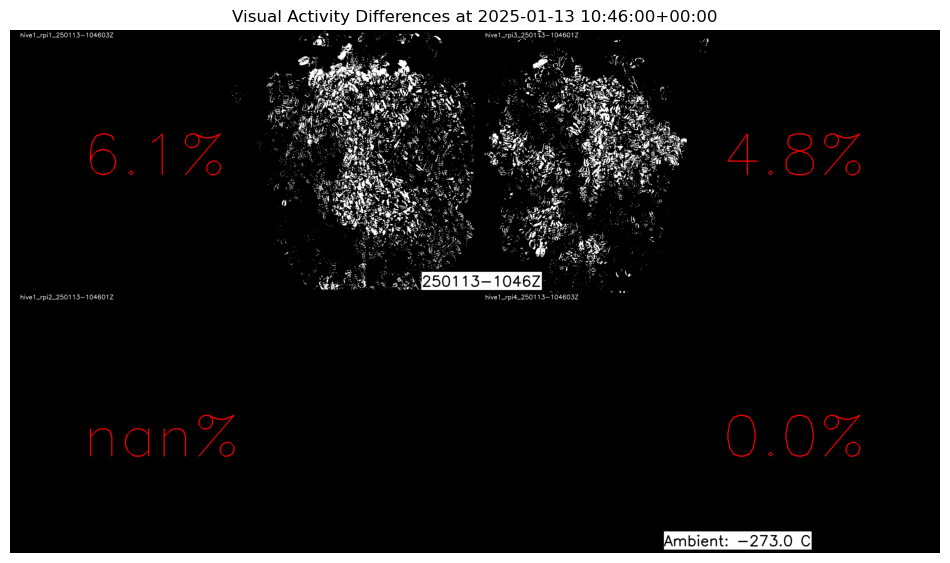

In [5]:
def generateAnnotatedSnapshots(index:int):
    snapshot = diff_hives[index].snapshot()
    _activities = activities[index]

    # Convert snapshot to RGB
    snapshot_rgb = cv2.cvtColor(snapshot, cv2.COLOR_BGR2RGB)
    # Annotate the snapshot with activity values : value 0 at the top left, value 1 at the bottom left, value 2 at the top right, value 3 at the bottom right
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 8
    font_color = (255, 0, 0)  # Red color
    thickness = 3
    cv2.putText(snapshot_rgb, f"{_activities.activity_values[0]*100:.1f}%", (300, 600), font, font_scale, font_color, thickness)
    cv2.putText(snapshot_rgb, f"{_activities.activity_values[1]*100:.1f}%", (300, snapshot_rgb.shape[0] - 400), font, font_scale, font_color, thickness)
    cv2.putText(snapshot_rgb, f"{_activities.activity_values[2]*100:.1f}%", (snapshot_rgb.shape[1] - 900, 600), font, font_scale, font_color, thickness)
    cv2.putText(snapshot_rgb, f"{_activities.activity_values[3]*100:.1f}%", (snapshot_rgb.shape[1] - 900, snapshot_rgb.shape[0] - 400), font, font_scale, font_color, thickness)
    return snapshot_rgb

index = 5  # Change index to visualize different time points
snapshot_rgb = generateAnnotatedSnapshots(index)

plt.figure(figsize=(12, 8))
plt.imshow(snapshot_rgb)
plt.axis('off')
plt.title(f"Visual Activity Differences at {diff_hives[index].ts}")
plt.show()

### Save video

In [9]:
dest = 'outputVideos'
filename = f'hive{hive_nb}_{threshold}_{start_ts.strftime("%Y%m%d_%H%M")}_{(start_ts + time_window).strftime("%Y%m%d_%H%M")}'
video = initVideoWriter(dest, shape=diff_hives[1].snapshot().shape, name=filename, fps=15) # RGB video
for idx in tqdm(range(0, len(diff_hives))):
    snapshot_rgb = generateAnnotatedSnapshots(idx)
    video.write(cv2.cvtColor(snapshot_rgb, cv2.COLOR_RGB2BGR))  # Convert back to BGR for video writing

video.release()


100%|██████████| 360/360 [00:30<00:00, 11.90it/s]


## Figures

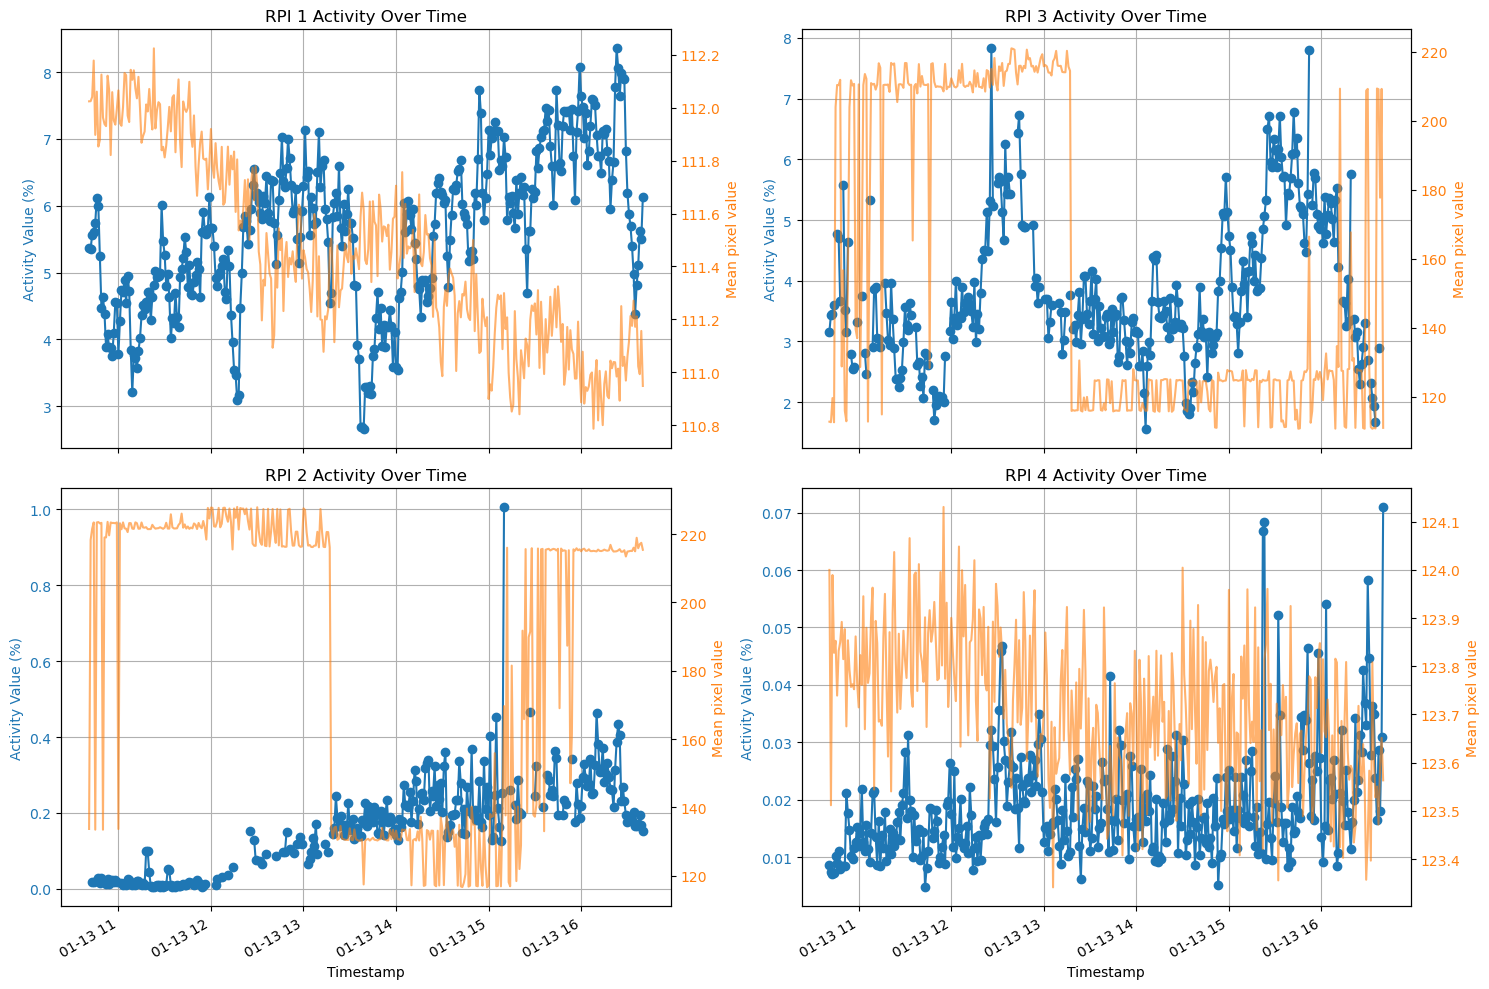

In [7]:
# Plot the activity values over time for each of the four rpis, along with the mean pixel
# value of each RPi's image (as a rough proxy for exposure level) on a secondary y-axis
from concurrent.futures import ThreadPoolExecutor

timestamps = pd.to_datetime([act.ts for act in activities])

def compute_mean(filepath):
    if filepath is None:
        return np.nan
    # IMREAD_REDUCED_COLOR_4 decodes the JPEG at 1/4 resolution, which is much faster
    # than decoding full-size, and is plenty accurate for a mean-pixel-value estimate.
    img = cv2.imread(filepath, cv2.IMREAD_REDUCED_COLOR_4)
    return img.mean() if img is not None else np.nan

# activities[i].ts corresponds to imgs_paths.index[i+1] (the later timestamp of each consecutive pair)
rpi_img_paths = imgs_paths.iloc[1:]
with ThreadPoolExecutor() as executor:
    mean_pixel_values = {col: list(executor.map(compute_mean, rpi_img_paths[col])) for col in rpi_img_paths.columns}

fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
for i in range(4):
    ax = axs[i%2, i//2]
    ax.plot(timestamps, [act.activity_values[i]*100 for act in activities], marker='o', color='tab:blue')
    ax.set_title(f'RPI {i+1} Activity Over Time')
    ax.set_ylabel('Activity Value (%)', color='tab:blue')
    ax.tick_params(axis='y', labelcolor='tab:blue')
    ax.grid()
    if i%2 == 1:
        ax.set_xlabel('Timestamp')

    ax2 = ax.twinx()
    ax2.plot(timestamps, mean_pixel_values[rpi_img_paths.columns[i]], color='tab:orange', alpha=0.6)
    ax2.set_ylabel('Mean pixel value', color='tab:orange')
    ax2.tick_params(axis='y', labelcolor='tab:orange')

# Save this plot in Downloads
plt.savefig('/Users/cyrilmonette/Downloads/rpi_activity_plot.png')

fig.autofmt_xdate()
plt.tight_layout()
plt.show()
